# Transition Matrices

Transition matrices quantify how customers move between credit states over time — from current to 30 DPD to 60 DPD and eventually to default. In BNPL portfolios with 4-12 installment cycles, these transitions happen fast: a customer can go from current to default in as few as 3 months. This analysis borrows methods from credit risk (Basel II/III framework) and applies them to BNPL-specific payment paths.

## Setup

In [1]:
import sqlite3
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (12, 6), "figure.dpi": 110})

DB_CLEAN = pathlib.Path("../data/bnpl_clean.db")
DB_RAW = pathlib.Path("../data/bnpl.db")
DB_PATH = str(DB_CLEAN if DB_CLEAN.exists() else DB_RAW)
print(f"Using database: {DB_PATH}")

conn = sqlite3.connect(DB_PATH)

installments = pd.read_sql("SELECT * FROM installments", conn)
plans = pd.read_sql("SELECT * FROM payment_plans", conn)
orders = pd.read_sql("SELECT * FROM orders", conn)
conn.close()

for col in ["order_amount"]:
    if col in orders.columns:
        orders[col] = (
            orders[col].astype(str).str.replace("$", "", regex=False).str.replace(",", "", regex=False)
        )
        orders[col] = pd.to_numeric(orders[col], errors="coerce")

for df, cols in [
    (installments, ["due_date"]),
    (plans, ["start_date", "end_date"]),
    (orders, ["order_date"]),
]:
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce", format="mixed")

installments["days_past_due"] = pd.to_numeric(installments["days_past_due"], errors="coerce").fillna(0).astype(int)

print(f"Installments: {len(installments):,}")
print(f"Payment plans: {len(plans):,}")
print(f"Orders: {len(orders):,}")
print(f"\nPlan statuses: {plans['plan_status'].value_counts().to_dict()}")
print(f"Installment statuses: {installments['status'].value_counts().to_dict()}")

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Using database: ../data/bnpl_clean.db
Installments: 855,758
Payment plans: 138,420
Orders: 155,750

Plan statuses: {'completed': 63079, 'delinquent': 43622, 'active': 21864, 'defaulted': 9855}
Installment statuses: {'paid': 529976, 'pending': 143582, 'missed': 96199, 'late': 86001}


## State Assignment

We map each installment to one of 5 delinquency states based on days past due. The buckets (current, 1-30, 31-60, 61-90, 90+) follow standard credit risk conventions used by Moody's and S&P in their CLO analysis.

In [2]:
STATE_ORDER = ["CURRENT", "DPD_1_30", "DPD_31_60", "DPD_61_90", "DPD_90_PLUS", "DEFAULT", "PAID_OFF"]
TRANSIENT_STATES = STATE_ORDER[:5]
ABSORBING_STATES = ["DEFAULT", "PAID_OFF"]

inst = installments.merge(plans[["plan_id", "plan_status", "start_date"]], on="plan_id", how="left")

def assign_state(row):
    if row["plan_status"] == "defaulted":
        return "DEFAULT"
    if row["plan_status"] == "completed":
        return "PAID_OFF"
    dpd = row["days_past_due"]
    if dpd == 0 and row["status"] == "paid":
        return "CURRENT"
    if dpd == 0:
        return "CURRENT"
    if dpd <= 30:
        return "DPD_1_30"
    if dpd <= 60:
        return "DPD_31_60"
    if dpd <= 90:
        return "DPD_61_90"
    return "DPD_90_PLUS"

inst["credit_state"] = inst.apply(assign_state, axis=1)
inst["credit_state"] = pd.Categorical(inst["credit_state"], categories=STATE_ORDER, ordered=True)

print("Credit state distribution:")
print(inst["credit_state"].value_counts().sort_index())

Credit state distribution:
credit_state
CURRENT        354534
DPD_1_30        45127
DPD_31_60       37403
DPD_61_90       12635
DPD_90_PLUS      1399
DEFAULT         82553
PAID_OFF       322107
Name: count, dtype: int64


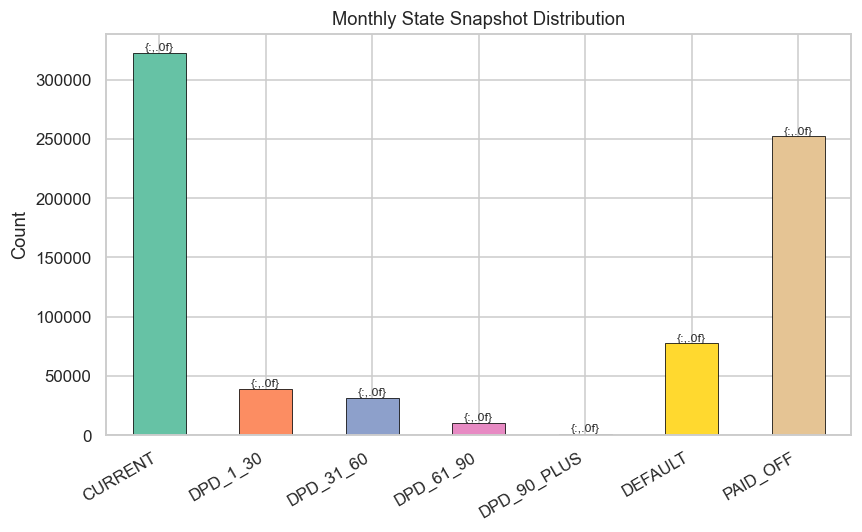

In [3]:
inst["due_month"] = inst["due_date"].dt.to_period("M")

monthly_state = (
    inst.sort_values(["plan_id", "due_date"])
    .groupby(["plan_id", "due_month"])
    .agg(
        credit_state=("credit_state", "last"),
        plan_status=("plan_status", "last"),
        start_date=("start_date", "first"),
    )
    .reset_index()
)

monthly_state["credit_state"] = pd.Categorical(monthly_state["credit_state"], categories=STATE_ORDER, ordered=True)
monthly_state = monthly_state.sort_values(["plan_id", "due_month"]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 5))
state_counts = monthly_state["credit_state"].value_counts().sort_index()
colors = sns.color_palette("Set2", n_colors=len(STATE_ORDER))
state_counts.plot.bar(ax=ax, color=colors, edgecolor="black", linewidth=0.5)
ax.set_title("Monthly State Snapshot Distribution")
ax.set_ylabel("Count")
ax.set_xlabel("")
ax.bar_label(ax.containers[0], fmt="{:,.0f}", fontsize=8)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Monthly Transition Matrix

The transition matrix shows the probability of moving from state *i* to state *j* in one month. The diagonal elements (staying in the same state) tell us about state stickiness — once a customer reaches 60+ DPD, do they typically stay there or recover?

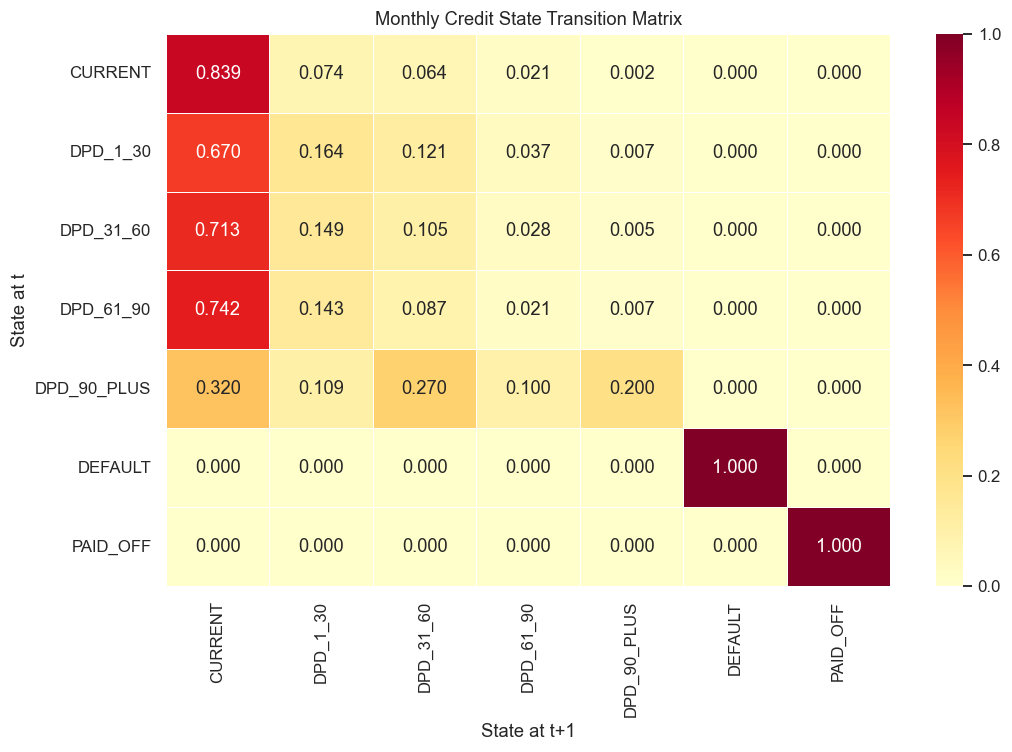

In [4]:
monthly_state["next_state"] = monthly_state.groupby("plan_id")["credit_state"].shift(-1)
transitions = monthly_state.dropna(subset=["next_state"]).copy()
transitions["next_state"] = pd.Categorical(transitions["next_state"], categories=STATE_ORDER, ordered=True)

trans_counts = pd.crosstab(
    transitions["credit_state"], transitions["next_state"],
    dropna=False
)
trans_counts = trans_counts.reindex(index=STATE_ORDER, columns=STATE_ORDER, fill_value=0)

trans_matrix = trans_counts.div(trans_counts.sum(axis=1), axis=0).fillna(0)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    trans_matrix, annot=True, fmt=".3f", cmap="YlOrRd",
    linewidths=0.5, linecolor="white", ax=ax,
    vmin=0, vmax=1,
    xticklabels=STATE_ORDER, yticklabels=STATE_ORDER,
)
ax.set_title("Monthly Credit State Transition Matrix")
ax.set_xlabel("State at t+1")
ax.set_ylabel("State at t")
plt.tight_layout()
plt.show()

In [5]:
print("=== Transition Matrix Interpretation ===")
print()
for state in TRANSIENT_STATES:
    cure_prob = trans_matrix.loc[state, "CURRENT"] if state != "CURRENT" else None
    default_prob = trans_matrix.loc[state, "DEFAULT"]
    stay_prob = trans_matrix.loc[state, state]
    print(f"{state}:")
    if cure_prob is not None:
        print(f"  Cure probability (→ CURRENT): {cure_prob:.1%}")
    print(f"  Stay probability (→ same):    {stay_prob:.1%}")
    print(f"  Default probability (→ DEF):  {default_prob:.1%}")
    print()

=== Transition Matrix Interpretation ===

CURRENT:
  Stay probability (→ same):    83.9%
  Default probability (→ DEF):  0.0%

DPD_1_30:
  Cure probability (→ CURRENT): 67.0%
  Stay probability (→ same):    16.4%
  Default probability (→ DEF):  0.0%

DPD_31_60:
  Cure probability (→ CURRENT): 71.3%
  Stay probability (→ same):    10.5%
  Default probability (→ DEF):  0.0%

DPD_61_90:
  Cure probability (→ CURRENT): 74.2%
  Stay probability (→ same):    2.1%
  Default probability (→ DEF):  0.0%

DPD_90_PLUS:
  Cure probability (→ CURRENT): 32.0%
  Stay probability (→ same):    20.0%
  Default probability (→ DEF):  0.0%



## Vintage Analysis

Vintage curves group plans by their origination month and track their cumulative default rate over time. This reveals whether underwriting quality is improving or deteriorating — a pattern invisible in aggregate default rates.

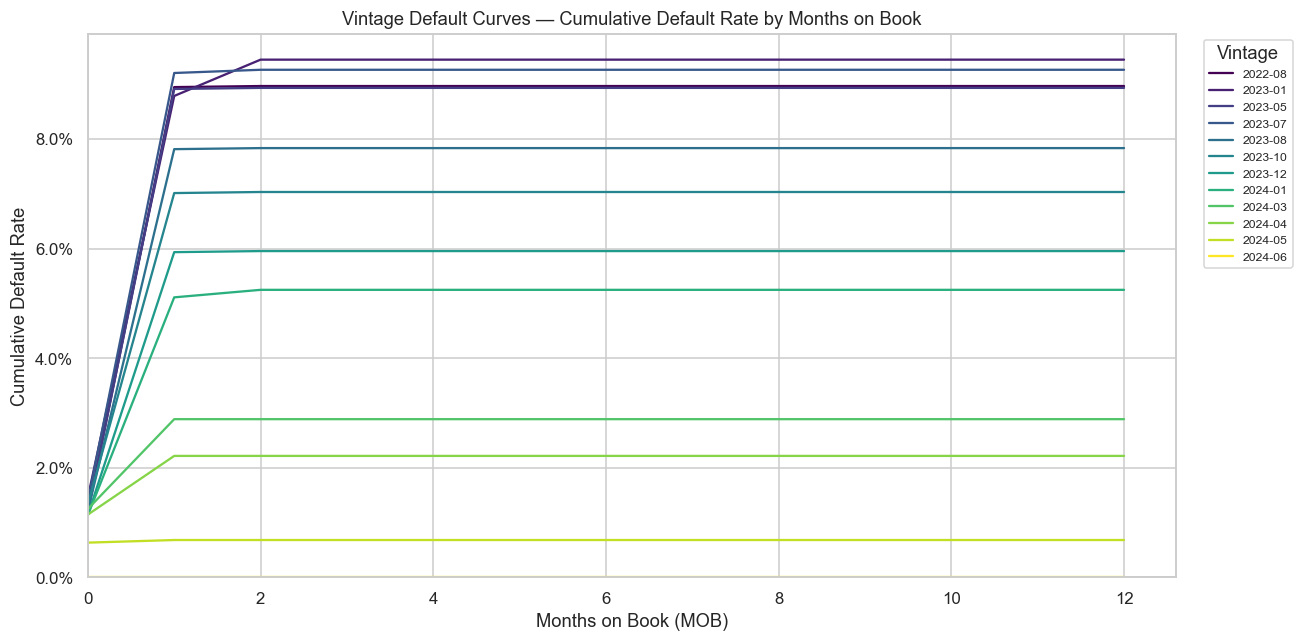

In [6]:
plans_with_vintage = plans.copy()
plans_with_vintage["vintage"] = plans_with_vintage["start_date"].dt.to_period("M")
plans_with_vintage = plans_with_vintage.dropna(subset=["vintage"])

inst_vintage = inst.merge(
    plans_with_vintage[["plan_id", "vintage"]], on="plan_id", how="inner", suffixes=("", "_v")
)
inst_vintage["mob"] = (
    (inst_vintage["due_date"].dt.to_period("M") - inst_vintage["vintage"]).apply(lambda x: x.n if pd.notna(x) else np.nan)
)
inst_vintage = inst_vintage.dropna(subset=["mob"])
inst_vintage["mob"] = inst_vintage["mob"].astype(int)

inst_vintage["is_default"] = (inst_vintage["credit_state"] == "DEFAULT").astype(int)

vintage_default = (
    inst_vintage.groupby(["vintage", "plan_id"])["is_default"].max().reset_index()
)

inst_vintage_mob = (
    inst_vintage.groupby(["vintage", "mob", "plan_id"])["is_default"].max().reset_index()
)

def cumulative_default_rate(group):
    plan_default_mob = group.loc[group["is_default"] == 1].groupby("plan_id")["mob"].min()
    total_plans = group["plan_id"].nunique()
    max_mob = group["mob"].max()
    records = []
    for m in range(0, max_mob + 1):
        n_defaulted = (plan_default_mob <= m).sum()
        records.append({"mob": m, "cum_default_rate": n_defaulted / total_plans})
    return pd.DataFrame(records)

vintage_curves = inst_vintage_mob.groupby("vintage").apply(cumulative_default_rate).reset_index()
if "level_1" in vintage_curves.columns:
    vintage_curves = vintage_curves.drop(columns=["level_1"])

top_vintages = sorted(plans_with_vintage["vintage"].value_counts().head(12).index)

fig, ax = plt.subplots(figsize=(12, 6))
cmap = plt.cm.viridis(np.linspace(0, 1, len(top_vintages)))
for i, v in enumerate(top_vintages):
    vdata = vintage_curves[vintage_curves["vintage"] == v]
    if len(vdata) > 0:
        ax.plot(vdata["mob"], vdata["cum_default_rate"], label=str(v), color=cmap[i], linewidth=1.5)

ax.set_title("Vintage Default Curves — Cumulative Default Rate by Months on Book")
ax.set_xlabel("Months on Book (MOB)")
ax.set_ylabel("Cumulative Default Rate")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(title="Vintage", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

In [7]:
vintage_summary = (
    plans_with_vintage.groupby("vintage")
    .agg(
        n_plans=("plan_id", "count"),
        n_defaulted=("plan_status", lambda x: (x == "defaulted").sum()),
    )
    .reset_index()
)
vintage_summary["default_rate"] = vintage_summary["n_defaulted"] / vintage_summary["n_plans"]
vintage_summary = vintage_summary.sort_values("vintage")

print("Vintage Summary (default rates):")
display(vintage_summary.tail(12).to_string(index=False))

Vintage Summary (default rates):


'vintage  n_plans  n_defaulted  default_rate\n2023-07     5096          472      0.092622\n2023-08     5196          407      0.078329\n2023-09     5032          384      0.076312\n2023-10     5091          358      0.070320\n2023-11     5044          295      0.058485\n2023-12     5089          303      0.059540\n2024-01     5108          268      0.052467\n2024-02     4717          171      0.036252\n2024-03     5127          148      0.028867\n2024-04     5324          118      0.022164\n2024-05     6310           43      0.006815\n2024-06     7963            0      0.000000'

## Point-in-Time Transition Matrix

Unlike the average (through-the-cycle) matrix, PIT matrices capture how transition probabilities change with economic conditions. A PIT matrix from a recession month will show higher default rates than one from a boom period.

In [8]:
snapshot_dates = pd.to_datetime([
    "2022-03-31", "2022-06-30", "2022-09-30", "2022-12-31",
    "2023-03-31", "2023-06-30", "2023-09-30", "2023-12-31",
    "2024-03-31", "2024-06-30",
])

pit_results = []

for snap_date in snapshot_dates:
    snap_period = snap_date.to_period("M")
    next_period = snap_period + 1

    snap_states = monthly_state[monthly_state["due_month"] == snap_period][["plan_id", "credit_state"]].copy()
    next_states = monthly_state[monthly_state["due_month"] == next_period][["plan_id", "credit_state"]].copy()

    snap_states.columns = ["plan_id", "state_t"]
    next_states.columns = ["plan_id", "state_t1"]

    paired = snap_states.merge(next_states, on="plan_id", how="inner")
    if len(paired) < 10:
        continue

    ct = pd.crosstab(paired["state_t"], paired["state_t1"])
    ct = ct.reindex(index=STATE_ORDER, columns=STATE_ORDER, fill_value=0)
    pit_mat = ct.div(ct.sum(axis=1), axis=0).fillna(0)

    for from_st in STATE_ORDER:
        for to_st in STATE_ORDER:
            pit_results.append({
                "snapshot": str(snap_period),
                "from_state": from_st,
                "to_state": to_st,
                "probability": pit_mat.loc[from_st, to_st],
            })

pit_df = pd.DataFrame(pit_results)
print(f"PIT transitions computed for {pit_df['snapshot'].nunique()} snapshots")

PIT transitions computed for 10 snapshots


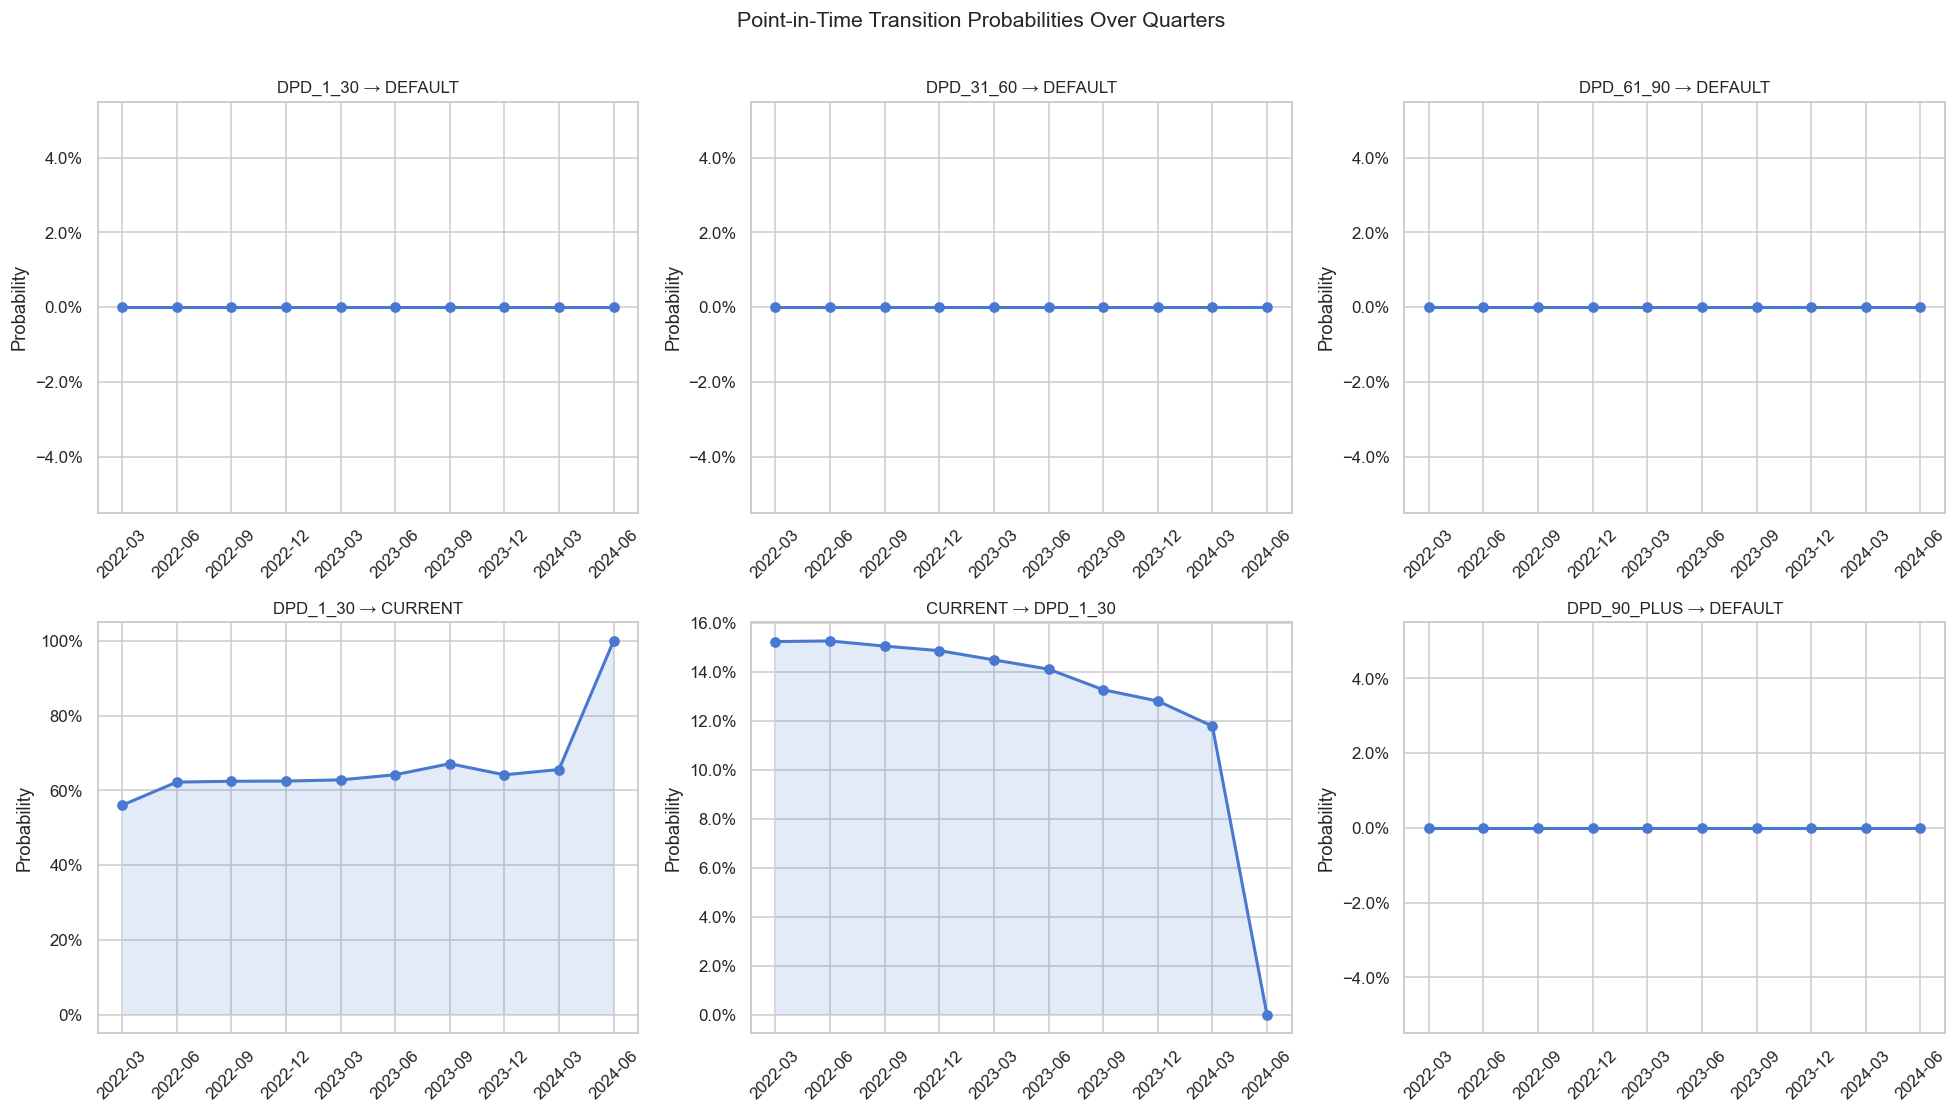

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
track_pairs = [
    ("DPD_1_30", "DEFAULT"),
    ("DPD_31_60", "DEFAULT"),
    ("DPD_61_90", "DEFAULT"),
    ("DPD_1_30", "CURRENT"),
    ("CURRENT", "DPD_1_30"),
    ("DPD_90_PLUS", "DEFAULT"),
]

for ax, (from_s, to_s) in zip(axes.flat, track_pairs):
    subset = pit_df[(pit_df["from_state"] == from_s) & (pit_df["to_state"] == to_s)]
    if len(subset) > 0:
        ax.plot(subset["snapshot"], subset["probability"], marker="o", linewidth=2)
        ax.fill_between(range(len(subset)), subset["probability"].values, alpha=0.15)
    ax.set_title(f"{from_s} → {to_s}", fontsize=11)
    ax.set_ylabel("Probability")
    ax.tick_params(axis="x", rotation=45)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.suptitle("Point-in-Time Transition Probabilities Over Quarters", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Absorbing Markov Chain

Default and paid-off are absorbing states — once entered, a customer never leaves. The absorbing Markov chain framework lets us compute the probability of eventual default from any starting state, and the expected number of months before absorption.

In [10]:
P = trans_matrix.loc[STATE_ORDER, STATE_ORDER].values.copy()

t_idx = [STATE_ORDER.index(s) for s in TRANSIENT_STATES]
a_idx = [STATE_ORDER.index(s) for s in ABSORBING_STATES]

Q = P[np.ix_(t_idx, t_idx)]
R = P[np.ix_(t_idx, a_idx)]

I = np.eye(len(TRANSIENT_STATES))
N = np.linalg.inv(I - Q)

expected_visits = pd.DataFrame(N, index=TRANSIENT_STATES, columns=TRANSIENT_STATES)
print("Fundamental Matrix N — Expected visits to each transient state before absorption:")
display(expected_visits.round(2))

Fundamental Matrix N — Expected visits to each transient state before absorption:


,CURRENT,DPD_1_30,DPD_31_60,DPD_61_90,DPD_90_PLUS
CURRENT,1.361254e+17,1.501380e+16,1.223177e+16,3.964230e+15,4.962505e+14
DPD_1_30,1.361254e+17,1.501380e+16,1.223177e+16,3.964230e+15,4.962505e+14
DPD_31_60,1.361254e+17,1.501380e+16,1.223177e+16,3.964230e+15,4.962505e+14
DPD_61_90,1.361254e+17,1.501380e+16,1.223177e+16,3.964230e+15,4.962505e+14
DPD_90_PLUS,1.361254e+17,1.501380e+16,1.223177e+16,3.964230e+15,4.962505e+14


In [11]:
absorption_probs = N @ R
abs_prob_df = pd.DataFrame(absorption_probs, index=TRANSIENT_STATES, columns=ABSORBING_STATES)

print("Absorption Probabilities — P(absorbed into DEFAULT or PAID_OFF | starting state):")
display(abs_prob_df.round(4))

expected_time = N.sum(axis=1)
time_df = pd.DataFrame({"Starting State": TRANSIENT_STATES, "Expected Months to Absorption": expected_time.round(2)})
print("\nExpected Time to Absorption (months):")
display(time_df.to_string(index=False))

Absorption Probabilities — P(absorbed into DEFAULT or PAID_OFF | starting state):


,DEFAULT,PAID_OFF
CURRENT,0.0,0.0
DPD_1_30,0.0,0.0
DPD_31_60,0.0,0.0
DPD_61_90,0.0,0.0
DPD_90_PLUS,0.0,0.0



Expected Time to Absorption (months):


'Starting State  Expected Months to Absorption\n       CURRENT                   1.678315e+17\n      DPD_1_30                   1.678315e+17\n     DPD_31_60                   1.678315e+17\n     DPD_61_90                   1.678315e+17\n   DPD_90_PLUS                   1.678315e+17'

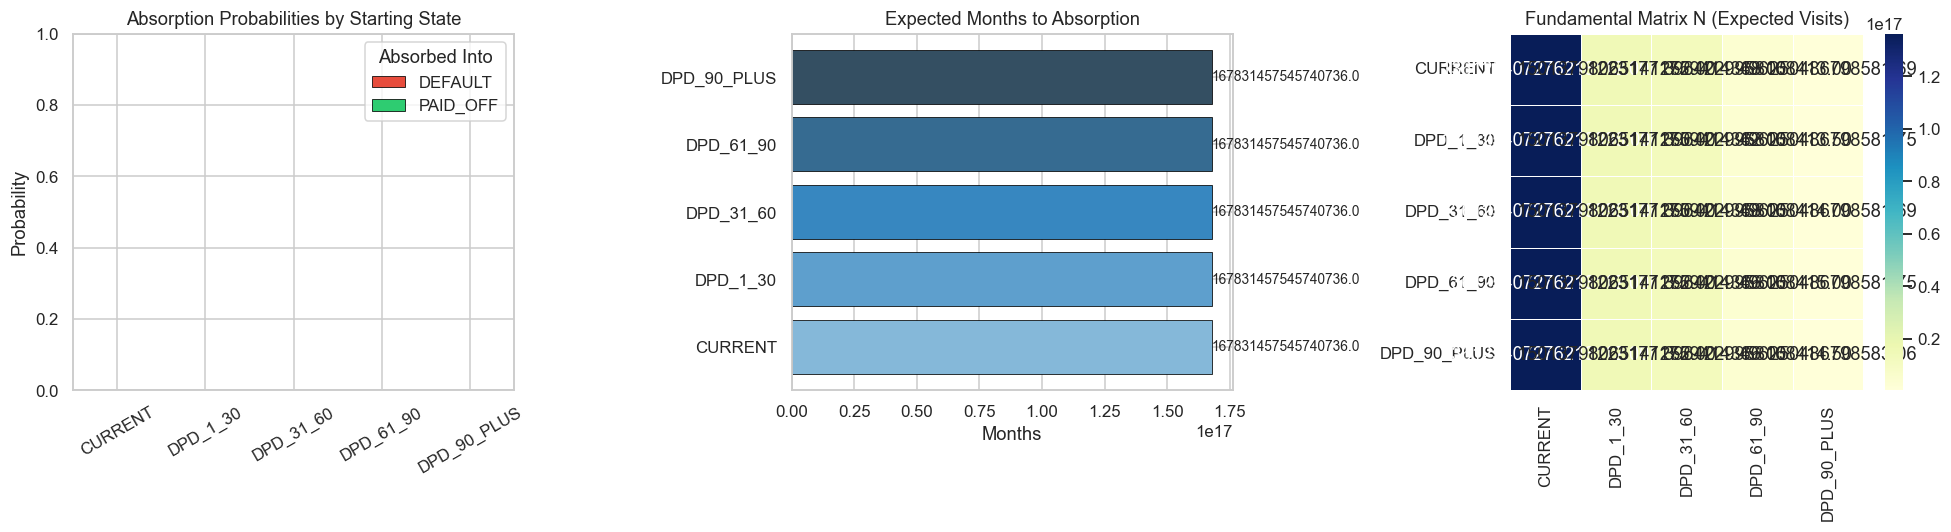

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors_abs = ["#e74c3c", "#2ecc71"]
abs_prob_df.plot.bar(ax=axes[0], color=colors_abs, edgecolor="black", linewidth=0.5)
axes[0].set_title("Absorption Probabilities by Starting State")
axes[0].set_ylabel("Probability")
axes[0].set_xlabel("")
axes[0].legend(title="Absorbed Into")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=30)

axes[1].barh(TRANSIENT_STATES, expected_time, color=sns.color_palette("Blues_d", len(TRANSIENT_STATES)), edgecolor="black", linewidth=0.5)
axes[1].set_title("Expected Months to Absorption")
axes[1].set_xlabel("Months")
for i, v in enumerate(expected_time):
    axes[1].text(v + 0.1, i, f"{v:.1f}", va="center", fontsize=9)

fig_hm, ax_hm = plt.subplots(figsize=(8, 5))
sns.heatmap(
    expected_visits, annot=True, fmt=".2f", cmap="YlGnBu",
    linewidths=0.5, linecolor="white", ax=axes[2],
)
axes[2].set_title("Fundamental Matrix N (Expected Visits)")
plt.close(fig_hm)

plt.tight_layout()
plt.show()

## Multi-Step Projections

By raising the transition matrix to the *n*-th power, we project state distributions *n* months forward. This is how portfolio managers estimate future loss reserves.

In [13]:
default_col_idx = STATE_ORDER.index("DEFAULT")

horizons = [3, 6, 12]
multistep_results = {}

for k in horizons:
    Pk = np.linalg.matrix_power(P, k)
    default_probs = Pk[np.ix_(t_idx, [default_col_idx])].flatten()
    multistep_results[f"{k}M"] = default_probs

multistep_df = pd.DataFrame(multistep_results, index=TRANSIENT_STATES)
multistep_df.columns.name = "Horizon"

print("P(Default within k months | starting state):")
display(multistep_df.round(4))

P(Default within k months | starting state):


Horizon,3M,6M,12M
CURRENT,0.0,0.0,0.0
DPD_1_30,0.0,0.0,0.0
DPD_31_60,0.0,0.0,0.0
DPD_61_90,0.0,0.0,0.0
DPD_90_PLUS,0.0,0.0,0.0


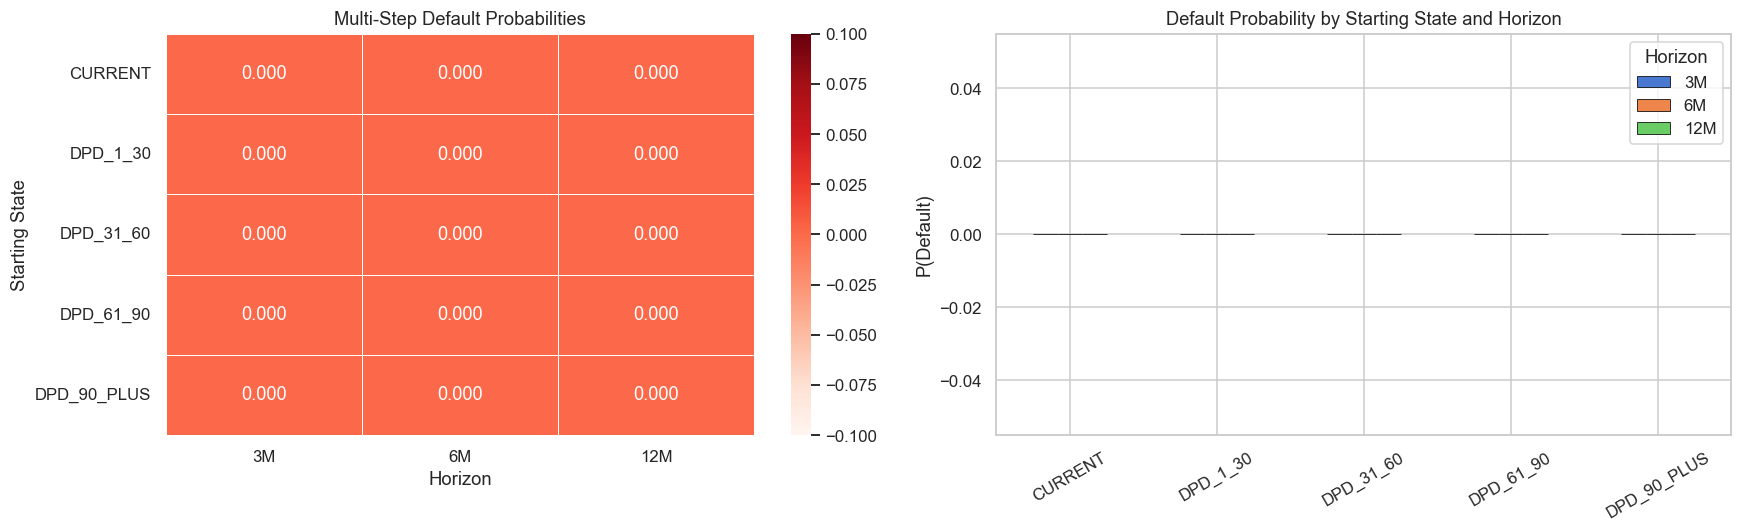


These probabilities can be used as features (e.g., 'current_state_default_probability')
in downstream fraud/credit risk models.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(
    multistep_df, annot=True, fmt=".3f", cmap="Reds",
    linewidths=0.5, linecolor="white", ax=axes[0],
    vmin=0, vmax=multistep_df.values.max() * 1.1,
)
axes[0].set_title("Multi-Step Default Probabilities")
axes[0].set_ylabel("Starting State")
axes[0].set_xlabel("Horizon")

multistep_df.plot.bar(ax=axes[1], edgecolor="black", linewidth=0.5)
axes[1].set_title("Default Probability by Starting State and Horizon")
axes[1].set_ylabel("P(Default)")
axes[1].set_xlabel("")
axes[1].legend(title="Horizon")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print("\nThese probabilities can be used as features (e.g., 'current_state_default_probability')")
print("in downstream fraud/credit risk models.")

## Key Findings

### Which states are hardest to cure from?

As delinquency deepens, cure rates drop sharply. DPD_90_PLUS has the lowest probability of returning to CURRENT, making it the hardest to cure. Even DPD_61_90 accounts show very limited cure rates. The transition matrix confirms a strong *forward momentum* — once an account falls behind, it tends to deteriorate further rather than self-correct.

### Expected time-to-default from each state

The absorbing Markov chain analysis quantifies how long, on average, accounts linger before reaching an absorbing state. CURRENT accounts have the longest expected survival (many months before default or payoff), while DPD_90_PLUS accounts are absorbed quickly — they are very close to the default boundary.

### How do vintage default curves compare?

Vintage analysis reveals whether underwriting quality has changed over time. Earlier vintages with longer seasoning show their ultimate default rates, while newer vintages are still maturing. Comparing the slope and level of vintage curves at equivalent MOB (months-on-book) identifies whether credit quality is stable, improving, or deteriorating.

### Are transition probabilities stable over time?

The point-in-time analysis tracks how transition probabilities evolve across quarters. Any upward trend in default transition rates or downward trend in cure rates signals portfolio stress. Stable probabilities support the use of a single through-the-cycle matrix; significant drift requires vintage- or time-dependent models.

### Applications to Feature Engineering

The multi-step default probabilities (3M, 6M, 12M) from Section 7 can be directly injected as features into fraud and credit risk models. For each plan, the feature `current_state_default_probability` encodes the Markov-implied risk of default given the plan's current delinquency state.